# Humedad, NDVI/EVI y PM10: ¿confusor o mediación?


**Pregunta a responder:** la humedad (RH) está correlacionada con el NDVI y con el PM10. ¿RH es la causa común que produce una correlación espuria entre NDVI y PM10 (confusor), o el NDVI media parte del efecto de RH sobre PM10 (RH → NDVI → PM10)? Y en cualquier caso, ¿cuál es el orden temporal entre las tres variables?

**Estructura:**
1. Carga y desestacionalización de los datos semanales (NE2, NE3)
2. Correlación parcial: NDVI vs PM10 controlando por RH
3. Análisis de mediación (bootstrap del efecto indirecto RH → NDVI → PM10)
4. Orden temporal: CCF con test de permutación para los 3 pares de variables
5. Robustez con EVI quincenal (índice de vegetación alternativo, menos sensible a saturación)
6. Resumen e interpretación

## 1. Carga y desestacionalización

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from statsmodels.tsa.seasonal import seasonal_decompose

pd.set_option('display.float_format', lambda x: f'{x:.4f}')


In [ ]:
NE2 = pd.read_csv('NE2_semanal_mediana_con_ndvi.csv')
NE3 = pd.read_csv('NE3_semanal_mediana_con_ndvi.csv')

for df in (NE2, NE3):
    df['fecha'] = pd.to_datetime(df['semana'])
    df.sort_values('fecha', inplace=True)
    df.reset_index(drop=True, inplace=True)

print('NE2:', NE2.shape, '  rango:', NE2['fecha'].min().date(), '->', NE2['fecha'].max().date())
print('NE3:', NE3.shape, '  rango:', NE3['fecha'].min().date(), '->', NE3['fecha'].max().date())
NE2[['fecha', 'PM10', 'RH', 'ndvi_mediana']].head()


NE2: (262, 28)   rango: 2020-12-28 -> 2025-12-29
NE3: (262, 28)   rango: 2020-12-28 -> 2025-12-29


,fecha,PM10,RH,ndvi_mediana
0,2020-12-28,40.5000,58.5000,NaN
1,2021-01-04,54.0000,43.0000,0.0436
2,2021-01-11,65.0000,55.5000,0.1117
3,2021-01-18,52.0000,82.0000,-0.0051
4,2021-01-25,51.0000,43.0000,0.0358


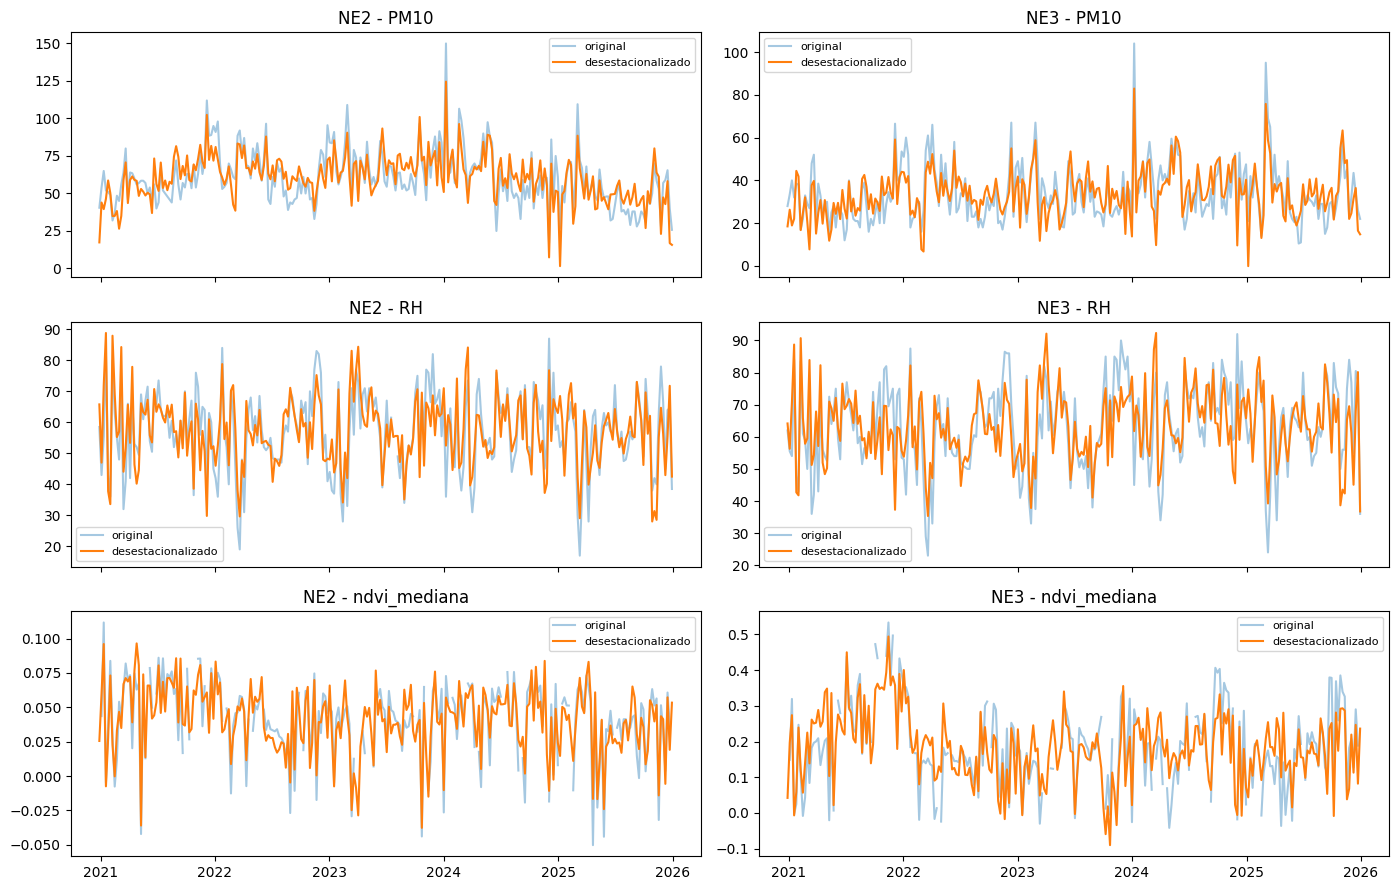

In [ ]:
def desestacionalizar(df, columnas, period=52):
    """Aplica seasonal_decompose (aditivo) a cada columna y agrega <col>_des.
    Requiere que la columna no tenga NaNs internos (se interpola linealmente antes)."""
    df = df.copy()
    for col in columnas:
        serie = df[col].interpolate(limit_direction='both')
        resultado = seasonal_decompose(serie, model='add', period=period)
        df[f'{col}_des'] = serie - resultado.seasonal
    return df

cols_a_desestacionalizar = ['PM10', 'RH', 'ndvi_mediana']
NE2 = desestacionalizar(NE2, cols_a_desestacionalizar)
NE3 = desestacionalizar(NE3, cols_a_desestacionalizar)

estaciones = {'NE2': NE2, 'NE3': NE3}

fig, axes = plt.subplots(3, 2, figsize=(14, 9), sharex=True)
for j, (nombre, df) in enumerate(estaciones.items()):
    for i, col in enumerate(cols_a_desestacionalizar):
        axes[i, j].plot(df['fecha'], df[col], alpha=0.4, label='original')
        axes[i, j].plot(df['fecha'], df[f'{col}_des'], label='desestacionalizado')
        axes[i, j].set_title(f'{nombre} - {col}')
        axes[i, j].legend(fontsize=8)
plt.tight_layout()
plt.show()


## 2. Correlación parcial: NDVI vs PM10 controlando por RH

La correlación parcial responde: *si RH se mantuviera constante, ¿seguiría habiendo relación entre NDVI y PM10?* Se calcula residualizando ambas variables contra RH (regresión lineal simple) y correlacionando esos residuos. Si la correlación parcial cae mucho respecto a la correlación cruda, es evidencia de que RH actúa como confusor.

In [ ]:
def residualizar(a, b):
    """Residuo de a después de remover la parte lineal explicada por b."""
    b1 = np.column_stack([b, np.ones_like(b)])
    coef, *_ = np.linalg.lstsq(b1, a, rcond=None)
    return a - b1 @ coef

def correlacion_parcial(df, x_col, y_col, z_col):
    sub = df[[x_col, y_col, z_col]].dropna()
    x, y, z = sub[x_col].values, sub[y_col].values, sub[z_col].values

    r_cruda, p_cruda = pearsonr(x, y)

    rx = residualizar(x, z)
    ry = residualizar(y, z)
    r_parcial, p_parcial = pearsonr(rx, ry)

    return {'n': len(sub), 'r_cruda': r_cruda, 'p_cruda': p_cruda,
            'r_parcial': r_parcial, 'p_parcial': p_parcial}

resultados_parcial = []
for nombre, df in estaciones.items():
    res = correlacion_parcial(df, 'ndvi_mediana_des', 'PM10_des', 'RH_des')
    res['estacion'] = nombre
    resultados_parcial.append(res)
    print(f"--- {nombre} (n={res['n']}) ---")
    print(f"  Correlación NDVI-PM10 cruda:    r={res['r_cruda']:.3f}  p={res['p_cruda']:.4f}")
    print(f"  Correlación NDVI-PM10 parcial (controlando RH): r={res['r_parcial']:.3f}  p={res['p_parcial']:.4f}")
    print()

pd.DataFrame(resultados_parcial)[['estacion', 'n', 'r_cruda', 'p_cruda', 'r_parcial', 'p_parcial']]


--- NE2 (n=262) ---
  Correlación NDVI-PM10 cruda:    r=0.216  p=0.0004
  Correlación NDVI-PM10 parcial (controlando RH): r=0.097  p=0.1173

--- NE3 (n=262) ---
  Correlación NDVI-PM10 cruda:    r=0.192  p=0.0017
  Correlación NDVI-PM10 parcial (controlando RH): r=0.087  p=0.1599



,estacion,n,r_cruda,p_cruda,r_parcial,p_parcial
0,NE2,262,0.2157,0.0004,0.0970,0.1173
1,NE3,262,0.1925,0.0017,0.0871,0.1599


**Cómo leer esto:** si `r_parcial` es mucho menor que `r_cruda` (y deja de ser significativo), apoya la hipótesis de que RH es un confusor y que la relación NDVI-PM10 no es directa. Si `r_parcial` se mantiene similar y significativo, la relación NDVI-PM10 sobrevive controlando por humedad, lo cual es más compatible con una mediación (o un efecto directo).

## 3. Análisis de mediación: ¿RH → NDVI → PM10?

Descompone el efecto de RH sobre PM10 en:
- **Efecto total (c):** coeficiente de RH sobre PM10, sin controlar por NDVI
- **Efecto directo (c'):** coeficiente de RH sobre PM10, controlando por NDVI
- **Efecto indirecto (a·b):** camino RH → NDVI → PM10, donde *a* es el efecto de RH sobre NDVI y *b* es el efecto de NDVI sobre PM10 controlando por RH

Si el efecto indirecto es significativamente distinto de cero (intervalo de bootstrap que no cruza cero), hay evidencia de mediación real vía NDVI. Si el intervalo incluye cero, no hay mediación — todo el efecto (si lo hay) es directo o el confusor domina.

In [ ]:
def ols_multi(y, X_cols_dict):
    """Regresión lineal múltiple simple vía mínimos cuadrados. Devuelve dict de coeficientes."""
    nombres = list(X_cols_dict.keys())
    X = np.column_stack(list(X_cols_dict.values()) + [np.ones_like(y)])
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    return dict(zip(nombres + ['intercepto'], coef))

def mediacion_bootstrap(df, rh_col, ndvi_col, pm10_col, n_boot=3000, seed=42):
    sub = df[[rh_col, ndvi_col, pm10_col]].dropna().reset_index(drop=True)
    rh, ndvi, pm10 = sub[rh_col].values, sub[ndvi_col].values, sub[pm10_col].values
    n = len(sub)

    def calcular_efectos(rh, ndvi, pm10):
        a = ols_multi(ndvi, {'rh': rh})['rh']                       # RH -> NDVI
        modelo_pm10 = ols_multi(pm10, {'ndvi': ndvi, 'rh': rh})     # PM10 ~ NDVI + RH
        b = modelo_pm10['ndvi']                                     # NDVI -> PM10 | RH
        c_prime = modelo_pm10['rh']                                 # efecto directo RH -> PM10 | NDVI
        c_total = ols_multi(pm10, {'rh': rh})['rh']                 # efecto total RH -> PM10
        return a, b, c_prime, c_total, a * b

    a_obs, b_obs, cp_obs, ct_obs, indirecto_obs = calcular_efectos(rh, ndvi, pm10)

    rng = np.random.default_rng(seed)
    indirectos_boot = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        _, _, _, _, ind = calcular_efectos(rh[idx], ndvi[idx], pm10[idx])
        indirectos_boot[i] = ind

    ci_low, ci_high = np.percentile(indirectos_boot, [2.5, 97.5])
    significativo = not (ci_low <= 0 <= ci_high)

    return {'n': n, 'a (RH->NDVI)': a_obs, 'b (NDVI->PM10|RH)': b_obs,
            "c' (efecto directo RH->PM10|NDVI)": cp_obs, 'c (efecto total RH->PM10)': ct_obs,
            'efecto_indirecto (a*b)': indirecto_obs,
            'IC_95_indirecto': (ci_low, ci_high), 'mediacion_significativa': significativo}

resultados_mediacion = []
for nombre, df in estaciones.items():
    res = mediacion_bootstrap(df, 'RH_des', 'ndvi_mediana_des', 'PM10_des')
    resultados_mediacion.append({'estacion': nombre, **res})
    print(f"--- {nombre} (n={res['n']}) ---")
    print(f"  a (RH -> NDVI)                 = {res['a (RH->NDVI)']:.4f}")
    print(f"  b (NDVI -> PM10 | RH)          = {res['b (NDVI->PM10|RH)']:.4f}")
    print(f"  c' (efecto directo RH -> PM10) = {res["c' (efecto directo RH->PM10|NDVI)"]:.4f}")
    print(f"  c  (efecto total RH -> PM10)   = {res['c (efecto total RH->PM10)']:.4f}")
    print(f"  Efecto indirecto (a*b)         = {res['efecto_indirecto (a*b)']:.4f}")
    print(f"  IC 95% bootstrap del indirecto = [{res['IC_95_indirecto'][0]:.4f}, {res['IC_95_indirecto'][1]:.4f}]")
    print(f"  -> {'HAY mediación significativa vía NDVI' if res['mediacion_significativa'] else 'NO hay mediación significativa vía NDVI'}")
    print()


--- NE2 (n=262) ---
  a (RH -> NDVI)                 = -0.0007
  b (NDVI -> PM10 | RH)          = 59.7608
  c' (efecto directo RH -> PM10) = -0.5276
  c  (efecto total RH -> PM10)   = -0.5703
  Efecto indirecto (a*b)         = -0.0427
  IC 95% bootstrap del indirecto = [-0.0995, 0.0082]
  -> NO hay mediación significativa vía NDVI

--- NE3 (n=262) ---
  a (RH -> NDVI)                 = -0.0021
  b (NDVI -> PM10 | RH)          = 9.1103
  c' (efecto directo RH -> PM10) = -0.5111
  c  (efecto total RH -> PM10)   = -0.5301
  Efecto indirecto (a*b)         = -0.0189
  IC 95% bootstrap del indirecto = [-0.0468, 0.0029]
  -> NO hay mediación significativa vía NDVI



## 4. Orden temporal: CCF con test de permutación para los 3 pares

Se calcula la correlación cruzada (CCF) sobre las series desestacionalizadas y diferenciadas (para reducir autocorrelación espuria), con un test de permutación que corrige por el problema de comparaciones múltiples de mirar muchos lags a la vez (igual que en el notebook anterior). Se hace para los 3 pares posibles, en ambas estaciones:

- **RH → NDVI**: ¿la humedad antecede a la vegetación?
- **RH → PM10**: ¿la humedad antecede al PM10?
- **NDVI → PM10**: ¿la vegetación antecede al PM10, más allá de lo que ya hace RH?

Convención: en la CCF de `ccf(x, y)`, un lag **positivo** significa que **x adelanta a y** (x en el pasado se correlaciona con y en el presente).

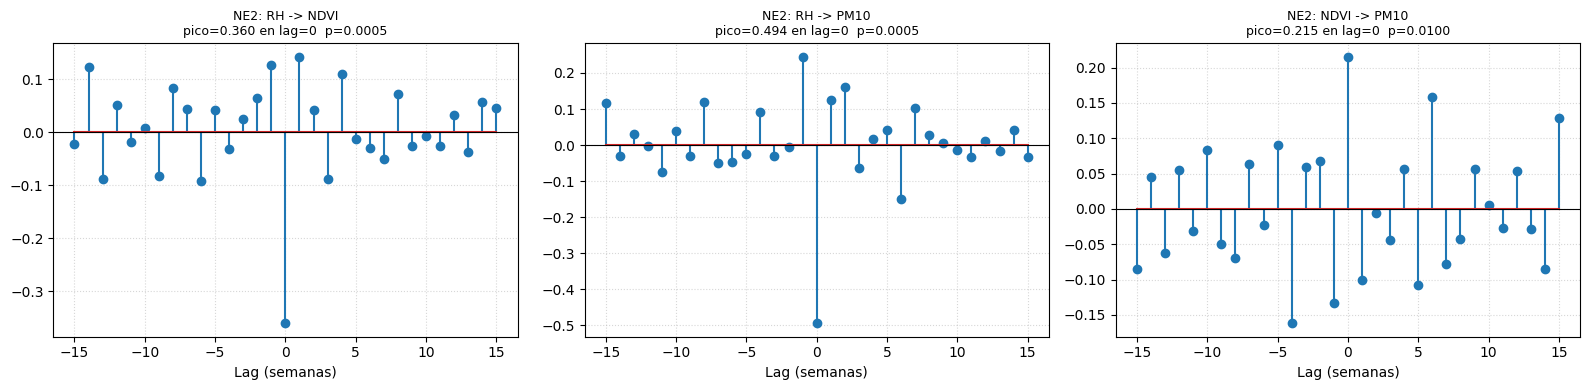

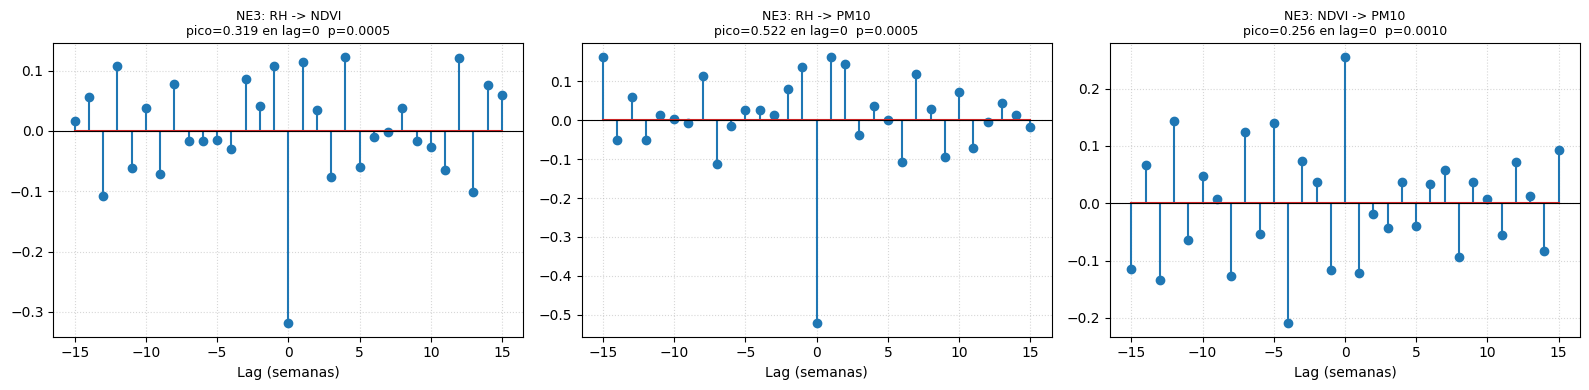

,estacion,par,n,pico_abs,lag_pico,p_value
0,NE2,RH -> NDVI,262,0.3604,0,0.0005
1,NE2,RH -> PM10,262,0.4944,0,0.0005
2,NE2,NDVI -> PM10,262,0.2154,0,0.0100
3,NE3,RH -> NDVI,262,0.3191,0,0.0005
4,NE3,RH -> PM10,262,0.5217,0,0.0005
5,NE3,NDVI -> PM10,262,0.2557,0,0.0010


In [ ]:
def ccf_bidireccional(x, y, max_lag=15):
    x = np.asarray(x); y = np.asarray(y)
    norm_x = (x - np.mean(x)) / (np.std(x) * len(x))
    norm_y = (y - np.mean(y)) / np.std(y)
    ccf_full = np.correlate(norm_x, norm_y, mode='full')
    mid = len(ccf_full) // 2
    return ccf_full[mid - max_lag: mid + max_lag + 1]

def permutation_test_ccf(x_raw, y_raw, max_lag=15, n_perm=2000, seed=42):
    rng = np.random.default_rng(seed)
    x = np.diff(np.asarray(x_raw))
    y = np.diff(np.asarray(y_raw))
    lags = np.arange(-max_lag, max_lag + 1)

    ccf_obs = ccf_bidireccional(x, y, max_lag)
    stat_obs = np.max(np.abs(ccf_obs))

    stat_null = np.empty(n_perm)
    for i in range(n_perm):
        y_shuff = rng.permutation(y)
        ccf_null = ccf_bidireccional(x, y_shuff, max_lag)
        stat_null[i] = np.max(np.abs(ccf_null))

    p_value = (np.sum(stat_null >= stat_obs) + 1) / (n_perm + 1)
    lag_pico = lags[np.argmax(np.abs(ccf_obs))]
    return lags, ccf_obs, stat_obs, lag_pico, p_value

pares = [('RH_des', 'ndvi_mediana_des', 'RH -> NDVI'),
         ('RH_des', 'PM10_des', 'RH -> PM10'),
         ('ndvi_mediana_des', 'PM10_des', 'NDVI -> PM10')]

resumen_ccf = []
for nombre, df in estaciones.items():
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    for ax, (col_x, col_y, etiqueta) in zip(axes, pares):
        sub = df[[col_x, col_y]].dropna()
        lags, ccf_obs, stat_obs, lag_pico, p_value = permutation_test_ccf(sub[col_x], sub[col_y])

        ax.stem(lags, ccf_obs)
        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_title(f'{nombre}: {etiqueta}\npico={stat_obs:.3f} en lag={lag_pico}  p={p_value:.4f}',
                     fontsize=9)
        ax.set_xlabel('Lag (semanas)')
        ax.grid(True, linestyle=':', alpha=0.5)

        resumen_ccf.append({'estacion': nombre, 'par': etiqueta, 'n': len(sub),
                             'pico_abs': stat_obs, 'lag_pico': lag_pico, 'p_value': p_value})
    plt.tight_layout()
    plt.show()

df_resumen_ccf = pd.DataFrame(resumen_ccf)
df_resumen_ccf


**Interpretación del signo del lag:** un `lag_pico` positivo en, por ejemplo, `RH -> NDVI` significa que la humedad de hace *lag_pico* semanas se correlaciona con el NDVI actual (RH antecede a NDVI) — consistente con que la humedad impulsa el crecimiento de vegetación. Si en `NDVI -> PM10` el lag significativo más fuerte es cercano a 0 o el patrón no es más fuerte que en `RH -> PM10`, es una señal de que NDVI no está aportando información temporal extra más allá de lo que ya aporta RH directamente.

## 5. Robustez con EVI quincenal

El EVI es menos sensible a saturación en vegetación densa y a efectos atmosféricos que el NDVI. Como es quincenal, se agregan PM10 y RH semanales a la misma resolución (promedio de las semanas dentro de cada ventana quincenal) en vez de interpolar el EVI, para no inventar información.

In [ ]:
EVI = pd.read_csv('EVI_estaciones.csv')
EVI['fecha'] = pd.to_datetime(EVI['fecha'])

def agregar_a_quincenal(df, fechas_evi):
    """Para cada fecha de EVI, promedia PM10_des y RH_des de las semanas
    dentro de la ventana [fecha, fecha + 14 días)."""
    filas = []
    fechas_evi = sorted(fechas_evi)
    for i, f in enumerate(fechas_evi):
        f_fin = fechas_evi[i + 1] if i + 1 < len(fechas_evi) else f + pd.Timedelta(days=14)
        ventana = df[(df['fecha'] >= f) & (df['fecha'] < f_fin)]
        if len(ventana) == 0:
            continue
        filas.append({'fecha': f, 'PM10_des': ventana['PM10_des'].mean(),
                       'RH_des': ventana['RH_des'].mean()})
    return pd.DataFrame(filas)

resultados_evi = []
for nombre, df in estaciones.items():
    evi_est = EVI[EVI['estacion'] == nombre].copy()
    agregado = agregar_a_quincenal(df, evi_est['fecha'])
    merged = pd.merge(agregado, evi_est[['fecha', 'EVI']], on='fecha', how='inner')

    # Desestacionalizar EVI también (periodo quincenal aprox. 26 obs/año)
    if len(merged) >= 52:
        merged['EVI_des'] = merged['EVI'] - seasonal_decompose(
            merged['EVI'].interpolate(limit_direction='both'), model='add', period=26).seasonal
    else:
        merged['EVI_des'] = merged['EVI'] - merged['EVI'].mean()  # fallback si hay pocos datos

    res = correlacion_parcial(merged, 'EVI_des', 'PM10_des', 'RH_des')
    res['estacion'] = nombre
    resultados_evi.append(res)
    print(f"--- {nombre} con EVI (n={res['n']}) ---")
    print(f"  Correlación EVI-PM10 cruda:    r={res['r_cruda']:.3f}  p={res['p_cruda']:.4f}")
    print(f"  Correlación EVI-PM10 parcial (controlando RH): r={res['r_parcial']:.3f}  p={res['p_parcial']:.4f}")
    print()

pd.DataFrame(resultados_evi)[['estacion', 'n', 'r_cruda', 'p_cruda', 'r_parcial', 'p_parcial']]


--- NE2 con EVI (n=115) ---
  Correlación EVI-PM10 cruda:    r=0.164  p=0.0797
  Correlación EVI-PM10 parcial (controlando RH): r=0.231  p=0.0131

--- NE3 con EVI (n=115) ---
  Correlación EVI-PM10 cruda:    r=0.104  p=0.2693
  Correlación EVI-PM10 parcial (controlando RH): r=0.192  p=0.0399



,estacion,n,r_cruda,p_cruda,r_parcial,p_parcial
0,NE2,115,0.1641,0.0797,0.2308,0.0131
1,NE3,115,0.1039,0.2693,0.1919,0.0399


**Cómo usar esta tabla de robustez:** si el patrón (correlación cruda significativa que cae al controlar por RH) se repite con EVI, es evidencia más fuerte de que el fenómeno es real y no un artefacto específico del NDVI. Si con EVI ni siquiera aparece la correlación cruda, hay que tomar los resultados de NDVI con más cautela — podría ser sensibilidad del índice, o simple variabilidad muestral con series cortas (n pequeño a resolución quincenal).

## 6. Resumen

Completar después de correr las celdas de arriba, usando esta guía:

| Pregunta | Evidencia a favor de **confusor puro** (RH causa ambas, sin relación NDVI-PM10) | Evidencia a favor de **mediación** (RH → NDVI → PM10) |
|---|---|---|
| Correlación parcial (Sección 2) | Cae hacia ~0 y pierde significancia al controlar por RH | Se mantiene similar y significativa |
| Efecto indirecto (Sección 3) | IC del bootstrap incluye 0 | IC del bootstrap no incluye 0 |
| CCF / orden temporal (Sección 4) | RH antecede a NDVI y a PM10 por separado, pero NDVI no aporta señal extra hacia PM10 | NDVI antecede a PM10 con un lag consistente y significativo, más allá del efecto directo de RH |
| Robustez con EVI (Sección 5) | El patrón de caída al controlar por RH se repite | (igual, apoya la fila correspondiente con más confianza) |

Con los resultados que ya tenías del notebook anterior (la contribución de NDVI dejaba de ser significativa en el modelo multivariado con meteorología), la expectativa previa es que la tabla se incline hacia la columna de **confusor puro** — pero solo se puede afirmar con lo que salga aquí.